In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# List your experiments here
# experiments = [
#     {"id": "exp_20250625_014444", "name": "Openwhisk"},
#     {"id": "exp_20250625_071954", "name": "Proposed"},
#     {"id": "exp_20250624_210136", "name": "Histogram"},
#     {"id": "exp_20250624_165438", "name": "Pagurus"},
# ]
experiments = [
    {"id": "exp_20250627_145610", "name": "Openwhisk"},
    {"id": "exp_20250627_103341", "name": "Proposed"},
    {"id": "exp_20250627_213220", "name": "Histogram"},
    {"id": "exp_20250628_065241", "name": "Pagurus"},
]

In [3]:
# import pandas as pd
# import json

def parse_json_safe(val):
    if pd.isna(val) or val == "None":
        return None
    if isinstance(val, dict):  # Already a dict
        return val
    try:
        return json.loads(val)
    except Exception:
        return None

def extract_name(res,name):
    if isinstance(res, dict):
        return res.get(name)
    return None




def extract_error_message(res):
    if isinstance(res, dict):
        resp = res.get("response", {})
        if not resp.get("success", True):
            return resp.get("result", {}).get("error")
    return None

def has_cuda_error(msg):
    if isinstance(msg, str):
        return "cuda" in msg.lower() or "cudnn" in msg.lower()
    return False

def extract_success(res):
    if isinstance(res, dict):
        return res.get("response", {}).get("success", True)
    return False



In [4]:
plt.figure(figsize=(4, 3.5))
results = {}
res_df = res
for exp in experiments:
    # load the CSV for this experiment
    path = f"../results/{exp['id']}/results_updated.csv"
    df = pd.read_csv(path)

    # parse JSON and compute latency
    df["result_parsed"] = df["result"].apply(parse_json_safe)
    df["name"] = df["result_parsed"].apply(lambda res: extract_name(res, "name"))
    df['name'] = df['name'].str.replace(r'_p$', '', regex=True)
    df["start"] = df["result_parsed"].apply(lambda res: extract_name(res, "start"))
    df["end"] = df["result_parsed"].apply(lambda res: extract_name(res, "end"))
    df['latency'] = (df['end'] - df['start'])/1000
    df["error_message"] = df["result_parsed"].apply(extract_error_message)
    df["has_cuda_or_cudnn_error"] = df["error_message"].apply(has_cuda_error)
    df["success"] = df["result_parsed"].apply(extract_success)
    df["error"] = df["result_parsed"].isna() | (~df["success"])
    error_counts = df['error'].value_counts()
    results[exp['name']] = {}
    results[exp['name']]['true_val'] = error_counts.get(True, 0)
    results[exp['name']]['false_val'] = error_counts.get(False, 0)
    results[exp['name']]['false_val'] = df['latency'].mean()
    df_valid = df[df["error"] != True]
    avg_latency_per_name_dict = df_valid.groupby("name")["latency"].mean().to_dict()
    print(avg_latency_per_name_dict)
    
   
    # df = df[df['latency'] < 300]

print(results)

NameError: name 'res' is not defined

<Figure size 400x350 with 0 Axes>

In [5]:
completed = [v['true_val'] for v in results.values()]
errors = [v['false_val'] for v in results.values()]
latencies = [v['latency'] for v in results.values()]

In [6]:
errors

[]

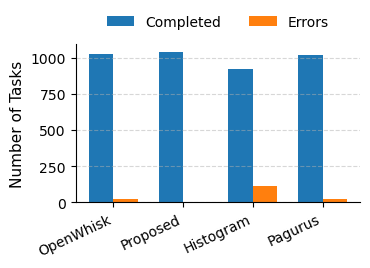

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Data
methods = ['OpenWhisk', 'Proposed', 'Histogram', 'Pagurus']
completed = [1021, 1039, 923, 1016]  # completed tasks
errors = [20, 0, 111, 25]            # errors

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(3.8, 2.8))

# Plotting bars
rects1 = ax.bar(x - width/2, completed, width, label='Completed')
rects2 = ax.bar(x + width/2, errors, width, label='Errors')

# Axis labels and title
ax.set_ylabel('Number of Tasks', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=25, ha='right',fontsize=10)
ax.tick_params(axis='both', labelsize=10)

# Move legend above the plot
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)

# Remove top and right spines for cleaner IEEE figure
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add subtle grid
ax.grid(axis='y', linestyle='--', alpha=0.5)

fig.tight_layout()
plt.savefig('graphs_images/task_completion_proposed.png', dpi=600, bbox_inches='tight')

plt.show()


In [36]:
latencies

[20, 0, 111, 25]

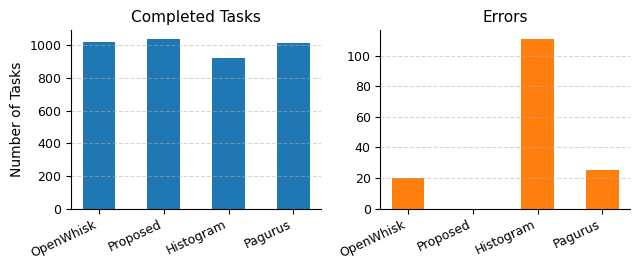

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Data
methods = ['OpenWhisk', 'Proposed', 'Histogram', 'Pagurus']
completed = [1021, 1039, 923, 1016]
errors = [20, 0, 111, 25]

x = np.arange(len(methods))
width = 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 2.8), sharex=True)

# Completed Tasks Bar
ax1.bar(x, completed, width, color='tab:blue')
ax1.set_title('Completed Tasks', fontsize=11)
ax1.set_ylabel('Number of Tasks', fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(methods, rotation=25, ha='right', fontsize=9)
ax1.tick_params(axis='y', labelsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Errors Bar
ax2.bar(x, errors, width, color='tab:orange')
ax2.set_title('Errors', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(methods, rotation=25, ha='right', fontsize=9)
ax2.tick_params(axis='y', labelsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()


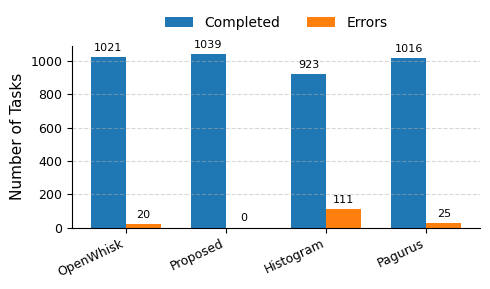

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Data
methods = ['OpenWhisk', 'Proposed', 'Histogram', 'Pagurus']
completed = [1021, 1039, 923, 1016]
errors = [20, 0, 111, 25]

x = np.arange(len(methods))
width = 0.35  # Bar width

fig, ax = plt.subplots(figsize=(5, 3))

# Bars for Completed and Errors
rects1 = ax.bar(x - width/2, completed, width, label='Completed', color='tab:blue')
rects2 = ax.bar(x + width/2, errors, width, label='Errors', color='tab:orange')

# Labels and ticks
ax.set_ylabel('Number of Tasks', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=10)
ax.tick_params(axis='both', labelsize=9)

# Add value labels on top of bars
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points above
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

add_labels(rects1)
add_labels(rects2)

# Legend and style
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()


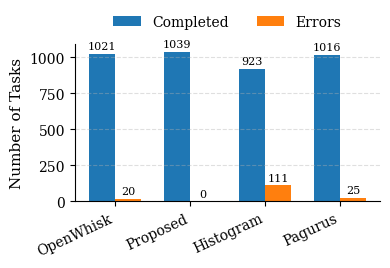

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['font.family'] = 'DejaVu Serif'
# Data
methods = ['OpenWhisk', 'Proposed', 'Histogram', 'Pagurus']
completed = [1021, 1039, 923, 1016]
errors = [20, 0, 111, 25]

x = np.arange(len(methods))
width = 0.35  # Bar width

fig, ax = plt.subplots(figsize=(4.0, 2.8))

# Grouped bars
rects1 = ax.bar(x - width/2, completed, width, label='Completed', color='tab:blue')
rects2 = ax.bar(x + width/2, errors, width, label='Errors', color='tab:orange')

# Axis labels and ticks
ax.set_ylabel('Number of Tasks', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=25, ha='right')
ax.tick_params(axis='both', labelsize=10)

# Value labels on bars
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 2),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

add_labels(rects1)
add_labels(rects2)

# Legend and style
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.tight_layout()
plt.savefig('graphs_images/task_completion.png', dpi=600, bbox_inches='tight')
plt.show()
